In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [76]:
df = pd.read_csv(r"C:\Users\HP\Downloads\transfusion.csv")
df

,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),whether he/she donated blood in March 2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0
...,...,...,...,...,...
743,23,2,500,38,0
744,21,2,500,52,0
745,23,3,750,62,0
746,39,1,250,39,0


In [77]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 5 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   Recency (months)                            748 non-null    int64
 1   Frequency (times)                           748 non-null    int64
 2   Monetary (c.c. blood)                       748 non-null    int64
 3   Time (months)                               748 non-null    int64
 4   whether he/she donated blood in March 2007  748 non-null    int64
dtypes: int64(5)
memory usage: 29.3 KB


In [78]:
df.shape

(748, 5)

In [79]:
df.columns

Index(['Recency (months)', 'Frequency (times)', 'Monetary (c.c. blood)',
       'Time (months)', 'whether he/she donated blood in March 2007'],
      dtype='object')

In [80]:
df.isnull().sum()

Recency (months)                              0
Frequency (times)                             0
Monetary (c.c. blood)                         0
Time (months)                                 0
whether he/she donated blood in March 2007    0
dtype: int64

In [81]:
df.describe()


,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),whether he/she donated blood in March 2007
count,748.000000,748.000000,748.000000,748.000000,748.000000
mean,9.506684,5.514706,1378.676471,34.282086,0.237968
std,8.095396,5.839307,1459.826781,24.376714,0.426124
min,0.000000,1.000000,250.000000,2.000000,0.000000
25%,2.750000,2.000000,500.000000,16.000000,0.000000
50%,7.000000,4.000000,1000.000000,28.000000,0.000000
75%,14.000000,7.000000,1750.000000,50.000000,0.000000
max,74.000000,50.000000,12500.000000,98.000000,1.000000


In [82]:
df.duplicated().sum()

np.int64(215)

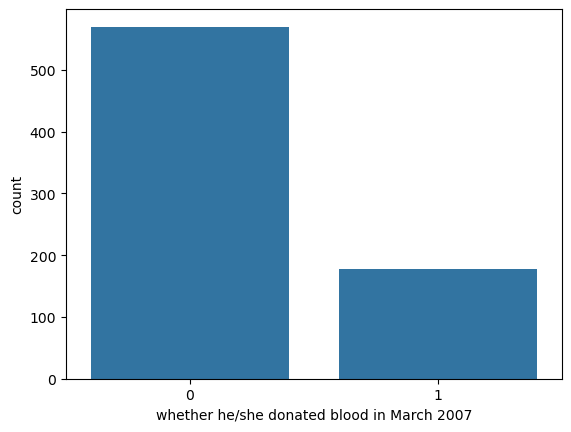

In [83]:
sns.countplot(
    x="whether he/she donated blood in March 2007",
    data=df
)
plt.show()

In [84]:
df_corr = df.corr()
df_corr

,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),whether he/she donated blood in March 2007
Recency (months),1.000000,-0.182745,-0.182745,0.160618,-0.279869
Frequency (times),-0.182745,1.000000,1.000000,0.634940,0.218633
Monetary (c.c. blood),-0.182745,1.000000,1.000000,0.634940,0.218633
Time (months),0.160618,0.634940,0.634940,1.000000,-0.035854
whether he/she donated blood in March 2007,-0.279869,0.218633,0.218633,-0.035854,1.000000


In [85]:
df_corr[["whether he/she donated blood in March 2007"]]

,whether he/she donated blood in March 2007
Recency (months),-0.279869
Frequency (times),0.218633
Monetary (c.c. blood),0.218633
Time (months),-0.035854
whether he/she donated blood in March 2007,1.000000


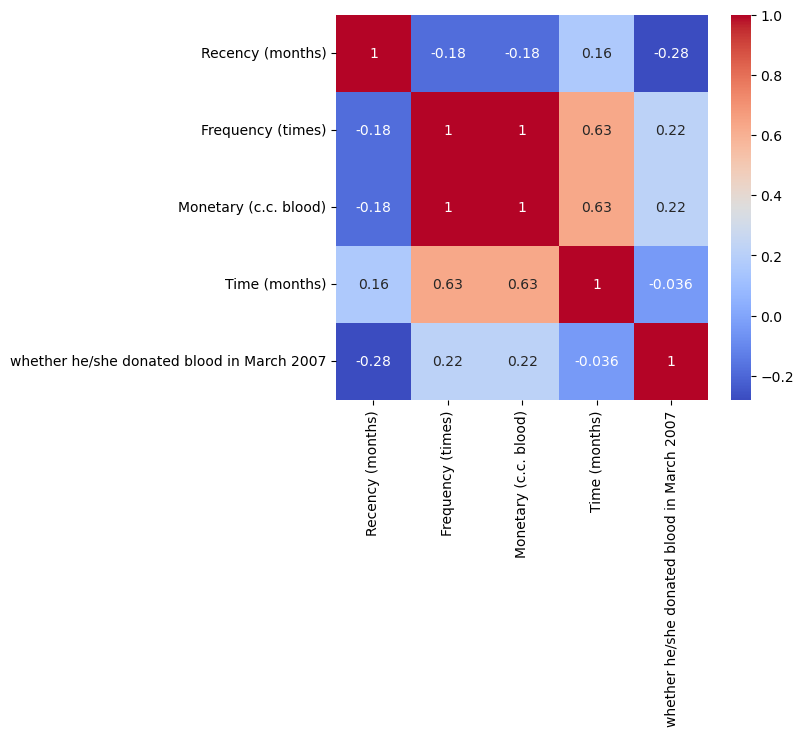

In [86]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

[]

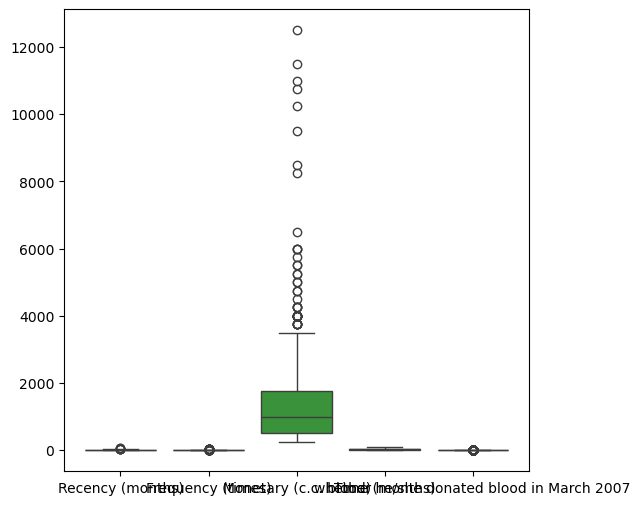

In [87]:
plt.figure(figsize =(6,6))
sns.boxplot(data = df)
plt.plot()

In [88]:
def remove_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q2 = df[col].quantile(0.50)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

    return df

In [89]:
target = 'whether he/she donated blood in March 2007'
columns_to_check = df.select_dtypes(include='number').columns.drop(target)
df_no_outliers = remove_outliers_iqr(df, columns_to_check)

print("Original DataFrame:")
print(df.shape)
print("\nDataFrame after Outlier Treatment (all columns):")
print(df_no_outliers.shape)

Original DataFrame:
(748, 5)

DataFrame after Outlier Treatment (all columns):
(655, 5)


In [90]:
print(df_no_outliers[target].value_counts())

whether he/she donated blood in March 2007
0    508
1    147
Name: count, dtype: int64


[]

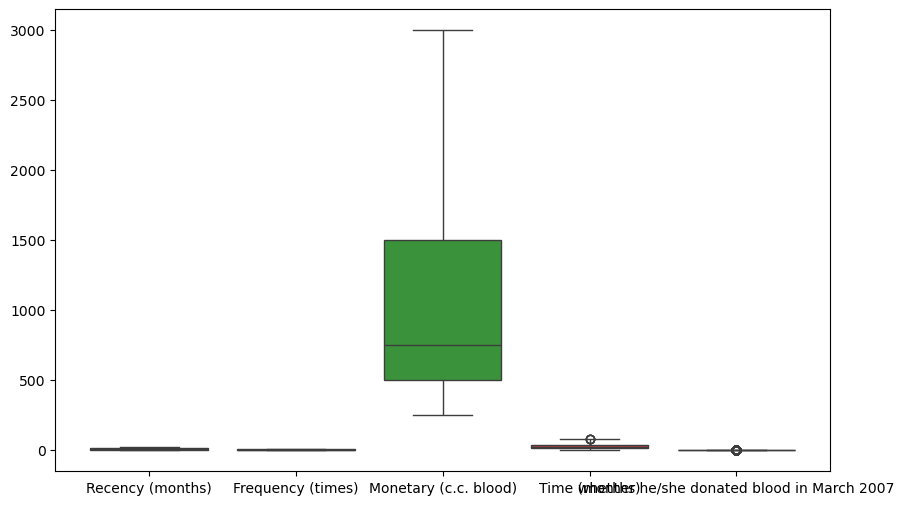

In [91]:
plt.figure(figsize = (10, 6))
sns.boxplot(data = df_no_outliers)
plt.plot()

In [92]:
x = df_no_outliers.drop('whether he/she donated blood in March 2007', axis=1)

# Target (dependent variable)
y = df_no_outliers['whether he/she donated blood in March 2007']

In [93]:
x.shape

(655, 4)

In [94]:
y.shape

(655,)

In [95]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [96]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [97]:

x_train


array([[ 0.23199203,  0.68727896,  0.68727896,  2.14435699],
       [-0.75633174,  0.3409961 ,  0.3409961 , -0.66948304],
       [ 0.65555936, -1.04413534, -1.04413534, -0.77180449],
       ...,
       [ 0.93793758, -0.00528676, -0.00528676, -0.31135794],
       [ 1.92626135, -0.00528676, -0.00528676,  1.22346389],
       [-0.75633174,  1.37984467,  1.37984467,  0.8653388 ]])

In [98]:
x_test

array([[ 0.65555936, -1.04413534, -1.04413534, -0.77180449],
       [-0.61514263,  1.03356181,  1.03356181, -0.15787576],
       [-1.03870996, -1.04413534, -1.04413534, -1.38573322],
       [ 0.65555936,  1.03356181,  1.03356181,  0.91649953],
       [ 0.65555936, -0.35156962, -0.35156962,  0.60953516],
       [ 1.92626135, -1.04413534, -1.04413534, -0.31135794],
       [-1.03870996, -0.69785248, -0.69785248, -1.28341177],
       [-1.03870996,  1.03356181,  1.03356181,  0.30257079],
       [ 0.51437025,  1.37984467,  1.37984467, -0.15787576],
       [-1.03870996, -0.69785248, -0.69785248, -1.28341177],
       [ 0.23199203, -0.69785248, -0.69785248, -0.77180449],
       [-1.03870996,  0.3409961 ,  0.3409961 , -0.15787576],
       [-0.89752085,  0.3409961 ,  0.3409961 , -0.87412595],
       [-1.03870996, -1.04413534, -1.04413534, -1.38573322],
       [-1.03870996, -0.00528676, -0.00528676, -0.66948304],
       [ 1.92626135, -0.00528676, -0.00528676,  1.17230317],
       [ 1.64388313, -1.

In [99]:
x

,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months)
5,4,4,1000,4
6,2,7,1750,14
7,1,12,3000,35
8,2,9,2250,22
11,0,3,750,4
...,...,...,...,...
739,23,4,1000,52
740,23,1,250,23
743,23,2,500,38
744,21,2,500,52


In [100]:
y

5      0
6      1
7      0
8      1
11     0
      ..
739    0
740    0
743    0
744    0
745    0
Name: whether he/she donated blood in March 2007, Length: 655, dtype: int64

In [101]:

%pip install tensorflow


Note: you may need to restart the kernel to use updated packages.


In [102]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [103]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
import datetime

In [104]:
x_train.shape

(524, 4)

In [105]:
x_train.shape[1]

4

In [106]:
from tensorflow.keras.layers import Input

model = Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [107]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                     │ (None, 64)                  │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

In [108]:
opt = tf.keras.optimizers.Adam(learning_rate=0.01)


In [109]:
model.compile(
    optimizer=opt,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [110]:
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

tensorflow_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1
)

In [111]:
early_stopping_callback = EarlyStopping(
    monitor='accuracy',
    patience=10,
    restore_best_weights=True
)

In [112]:
%pip install tensorboard

Note: you may need to restart the kernel to use updated packages.


In [113]:
history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    callbacks=[
        tensorflow_callback,
        early_stopping_callback
    ]
)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.7852 - loss: 0.5230 - val_accuracy: 0.7524 - val_loss: 0.5292
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8043 - loss: 0.4736 - val_accuracy: 0.8000 - val_loss: 0.5209
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8067 - loss: 0.4677 - val_accuracy: 0.7143 - val_loss: 0.5220
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8067 - loss: 0.4550 - val_accuracy: 0.7333 - val_loss: 0.5174
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8115 - loss: 0.4495 - val_accuracy: 0.7333 - val_loss: 0.5258
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8019 - loss: 0.4496 - val_accuracy: 0.7714 - val_loss: 0.5205
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8091 - loss: 0.4496 - val_accuracy: 0.7905 - val_loss: 0.5115
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8067 - loss: 0.4415 - val_accuracy: 0.

In [114]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

In [115]:
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.4543290138244629
Test Accuracy: 0.7633587718009949


In [116]:
y_pred_prob = model.predict(x_test)

y_pred = (y_pred_prob >= 0.5).astype(int).ravel()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step 


In [117]:

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.96      0.86       102
           1       0.33      0.07      0.11        29

    accuracy                           0.76       131
   macro avg       0.56      0.51      0.49       131
weighted avg       0.68      0.76      0.70       131



In [118]:
print(confusion_matrix(y_test, y_pred))

[[98  4]
 [27  2]]


In [119]:
model.save('transfusion_ann_model.h5')